In [70]:
import pandas as pd

In [71]:
df=pd.read_csv('/content/heart_2020_cleaned.csv.zip')

In [72]:
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

In [74]:
df.isnull().sum()

,0
HeartDisease,0
BMI,0
Smoking,0
AlcoholDrinking,0
Stroke,0
PhysicalHealth,0
MentalHealth,0
DiffWalking,0
Sex,0
AgeCategory,0


In [75]:
df.shape

(319795, 18)

In [76]:
x = df.drop(['HeartDisease'], axis=1)
y = df['HeartDisease']

In [77]:
x=pd.get_dummies(x)
x.head()

,BMI,PhysicalHealth,MentalHealth,SleepTime,Smoking_No,Smoking_Yes,AlcoholDrinking_No,AlcoholDrinking_Yes,Stroke_No,Stroke_Yes,...,GenHealth_Fair,GenHealth_Good,GenHealth_Poor,GenHealth_Very good,Asthma_No,Asthma_Yes,KidneyDisease_No,KidneyDisease_Yes,SkinCancer_No,SkinCancer_Yes
0,16.60,3.0,30.0,5.0,False,True,True,False,True,False,...,False,False,False,True,False,True,True,False,False,True
1,20.34,0.0,0.0,7.0,True,False,True,False,False,True,...,False,False,False,True,True,False,True,False,True,False
2,26.58,20.0,30.0,8.0,False,True,True,False,True,False,...,True,False,False,False,False,True,True,False,True,False
3,24.21,0.0,0.0,6.0,True,False,True,False,True,False,...,False,True,False,False,True,False,True,False,False,True
4,23.71,28.0,0.0,8.0,True,False,True,False,True,False,...,False,False,False,True,True,False,True,False,True,False


In [57]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score

In [78]:
scaler=StandardScaler()
x_encoded = pd.get_dummies(x)
x_train,x_test,y_train,y_test=train_test_split(x_encoded,y,test_size=0.3,random_state=42)
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [79]:
model=RandomForestClassifier()
model.fit(x_train,y_train)

RandomForestClassifier()

In [80]:
model.score(x_train,y_train)

0.9970650775498535

In [96]:
model.score(x_test,y_test)

0.9020002293123756

In [86]:
new_person = {
    'BMI': 62.42,
    'Smoking': 'Yes',
    'Stroke':'Yes',
    'AlcoholDrinking': 'Yes',
    'PhysicalHealth': 0,
    'MentalHealth': 0,
    'DiffWalking': 'Yes',
    'Sex': 'Female',
    'AgeCategory': '35-39',
    'Race': 'Black',
    'Diabetic': 'Yes',
    'PhysicalActivity': 'no',
    'GenHealth': 'poor',
    'SleepTime': 3,
    'Asthma': 'Yes',
    'KidneyDisease': 'Yes',
    'SkinCancer': 'Yes'
}

new_prediction_result = predict_heart_disease(new_person)
print(f"Prediction: {new_prediction_result['prediction']}")
print(f"Probability of HeartDisease: {new_prediction_result['probability_yes'] * 100:.2f}%")

Prediction: Yes
Probability of HeartDisease: 58.00%


In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

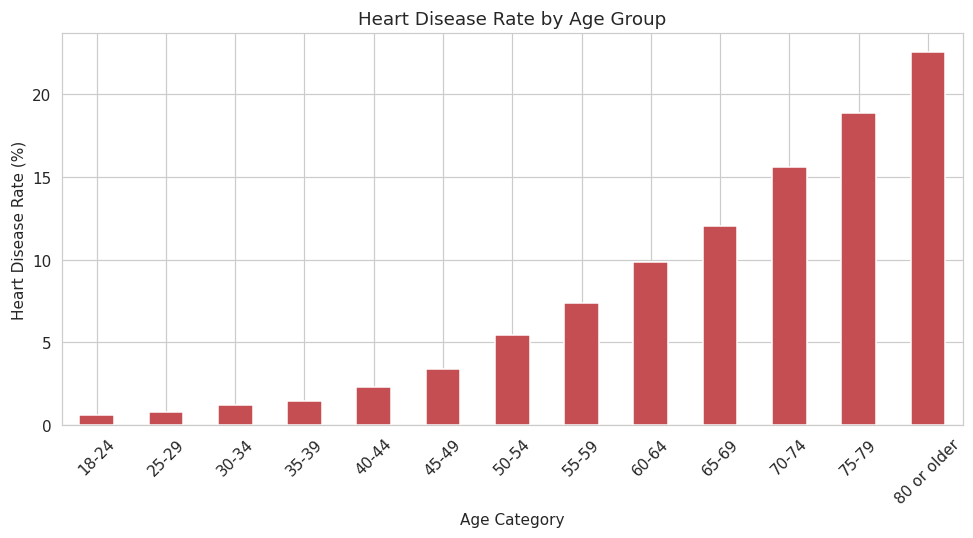

In [90]:
order = ['18-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59',
         '60-64','65-69','70-74','75-79','80 or older']
rate_age = df.groupby('AgeCategory')['HeartDisease'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reindex(order)

fig, ax = plt.subplots(figsize=(9, 5))
rate_age.plot(kind='bar', color='#C44E52', ax=ax)
ax.set_ylabel('Heart Disease Rate (%)')
ax.set_xlabel('Age Category')
ax.set_title('Heart Disease Rate by Age Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('1_rate_by_age.png')
plt.show()


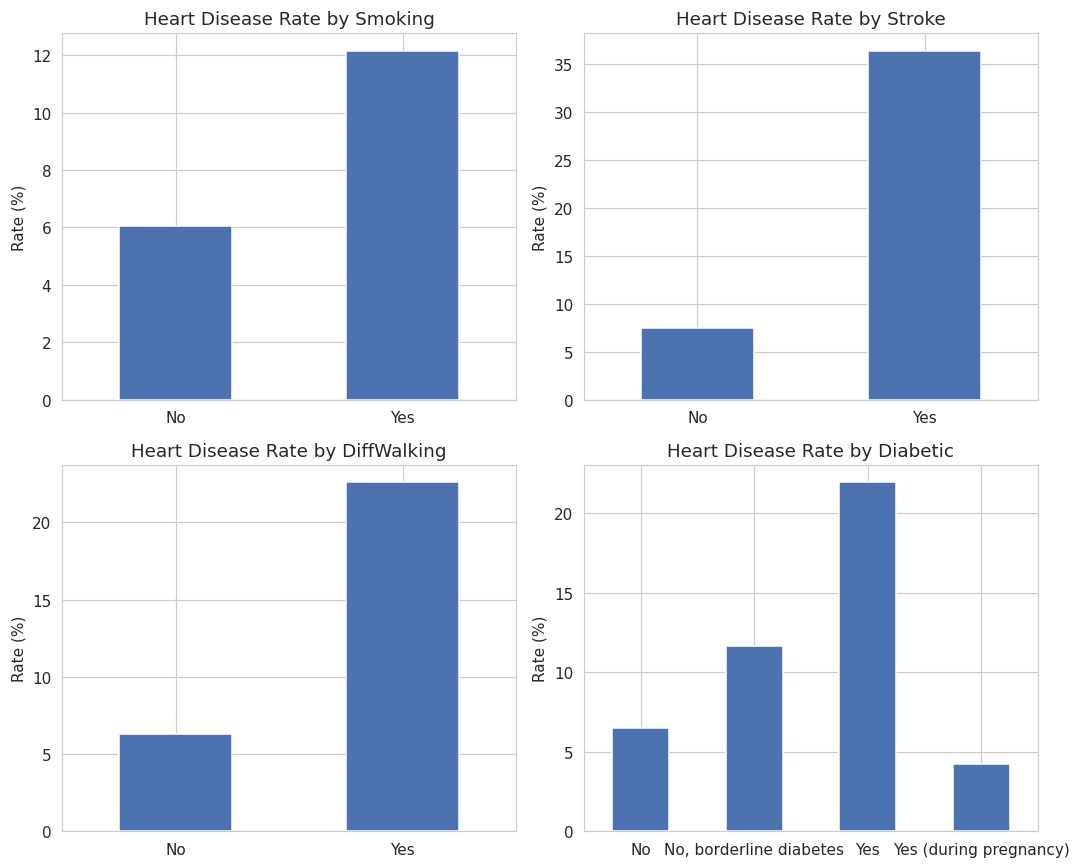

In [91]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
factors = ['Smoking', 'Stroke', 'DiffWalking', 'Diabetic']
for ax, col in zip(axes.flat, factors):
    rate = df.groupby(col)['HeartDisease'].apply(lambda x: (x == 'Yes').mean() * 100)
    rate.plot(kind='bar', ax=ax, color='#4C72B0')
    ax.set_title(f'Heart Disease Rate by {col}')
    ax.set_ylabel('Rate (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('2_rate_by_risk_factors.png')
plt.show()


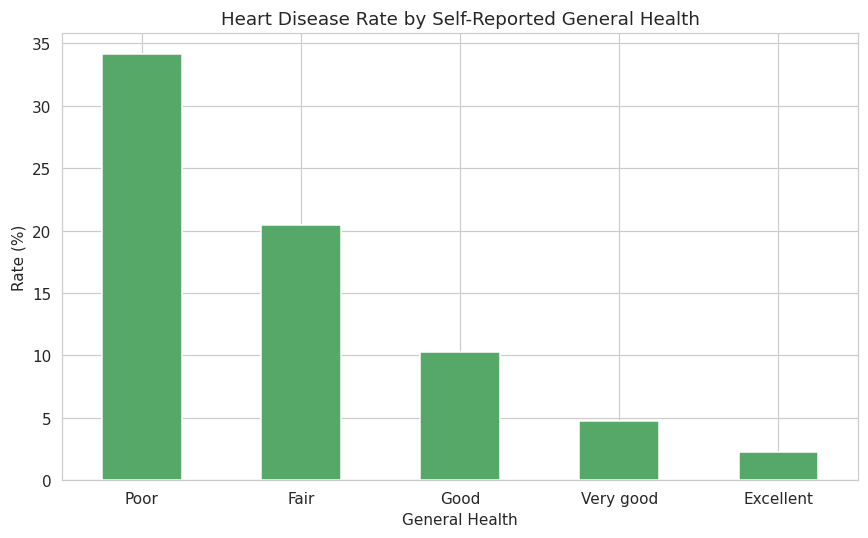

In [94]:
order_gh = ['Poor', 'Fair', 'Good', 'Very good', 'Excellent']
rate_gh = df.groupby('GenHealth')['HeartDisease'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reindex(order_gh)

fig, ax = plt.subplots(figsize=(8, 5))
rate_gh.plot(kind='bar', color='#55A868', ax=ax)
ax.set_title('Heart Disease Rate by Self-Reported General Health')
ax.set_ylabel('Rate (%)')
ax.set_xlabel('General Health')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('5_rate_by_genhealth.png')
plt.show()

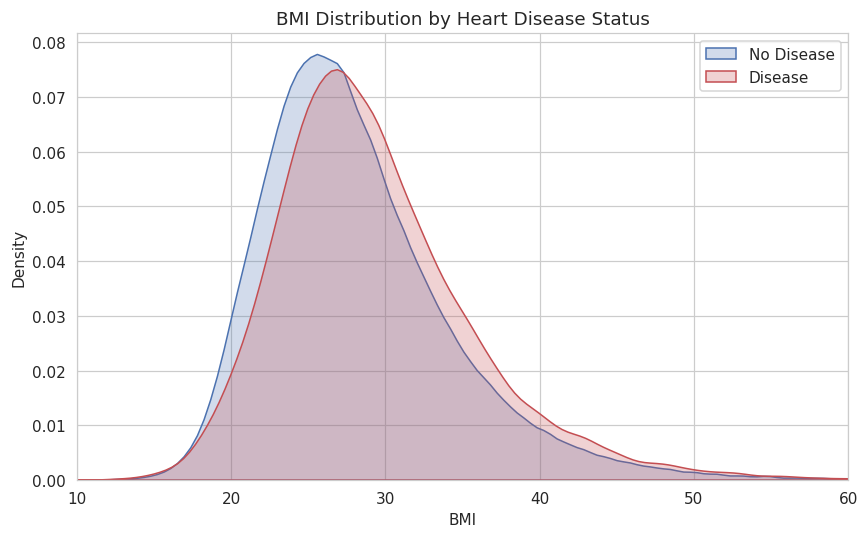

In [95]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(data=df[df['HeartDisease'] == 'No'], x='BMI', fill=True,
            label='No Disease', color='#4C72B0', ax=ax, common_norm=False)
sns.kdeplot(data=df[df['HeartDisease'] == 'Yes'], x='BMI', fill=True,
            label='Disease', color='#C44E52', ax=ax, common_norm=False)
ax.set_title('BMI Distribution by Heart Disease Status')
ax.set_xlim(10, 60)
ax.legend()
plt.tight_layout()
plt.savefig('3_bmi_distribution.png')
plt.show()
